In [6]:
import pandas as pd

# Load only the correct sheet with actual data
df = pd.read_excel('glass.xlsx', sheet_name='glass')  # 'glass' is the sheet name

# Now do your normal checks
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())


(214, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB
None
               RI          Na          Mg          Al          Si           K  \
count  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000   
mean     1.518365   13.407850    2.684533    1.444907   72.650935    0.497056   
std      0.003037    0.816604    1.442408    0.499270    0.774546    0.652192   
min      1.511150   10.730000    0.000000    0.290000   69.81

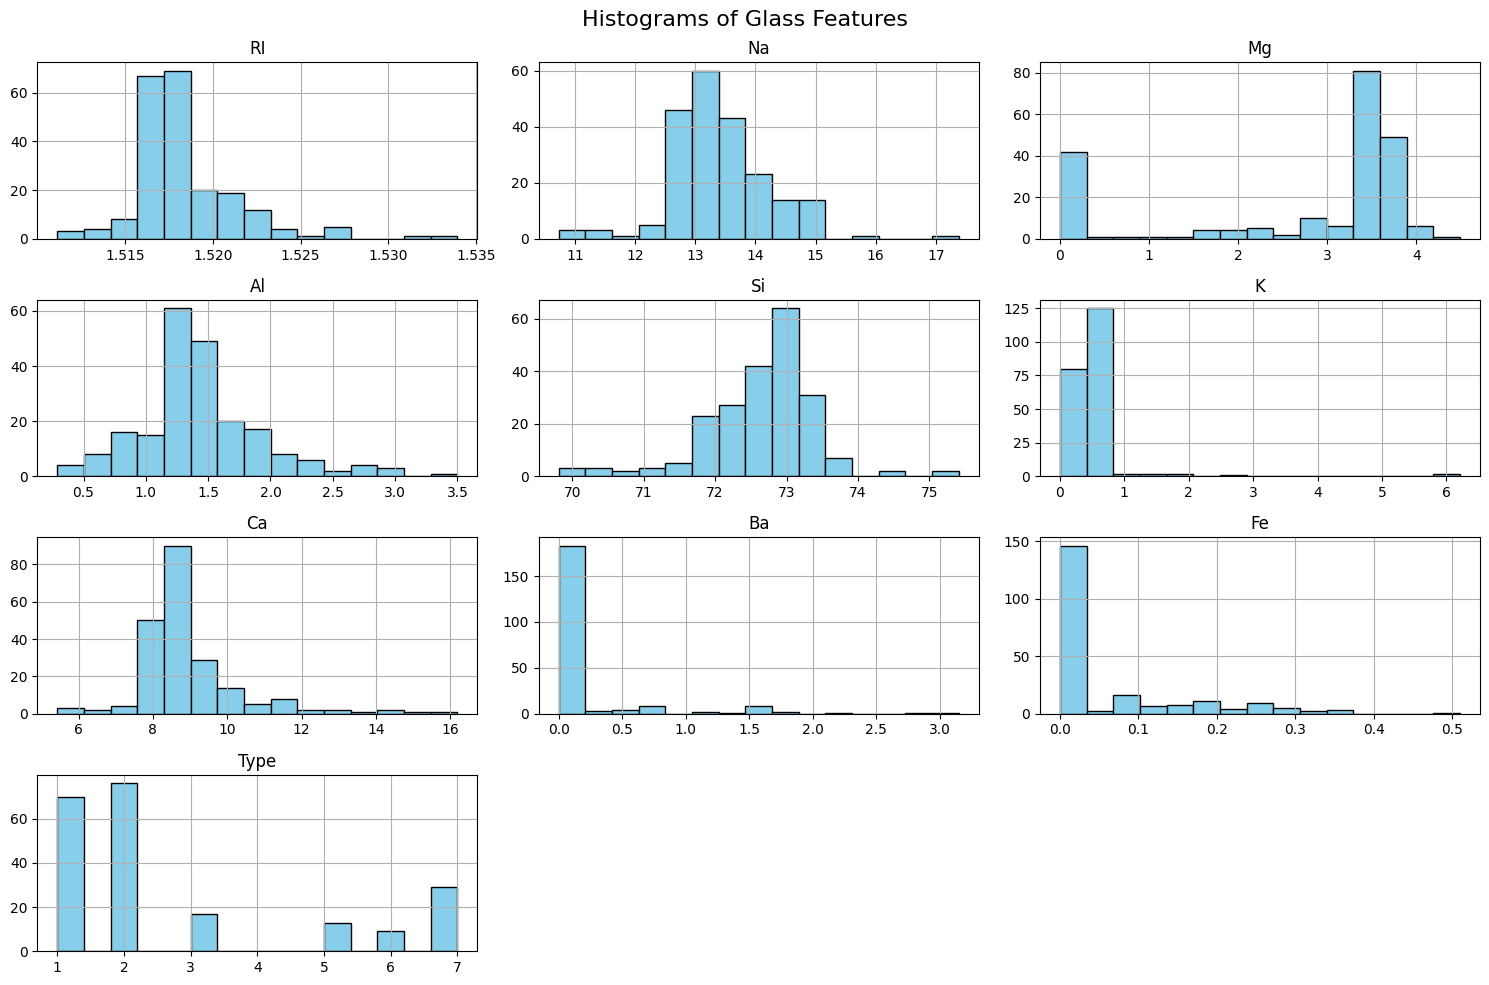

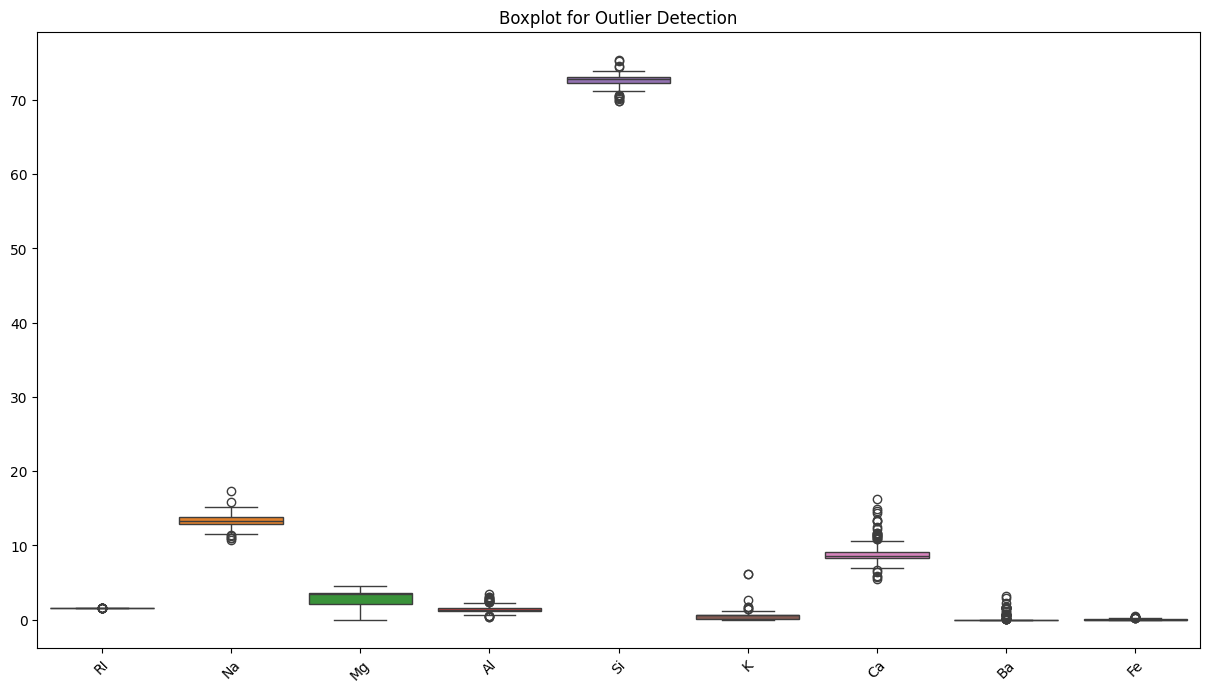

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot histograms
df.hist(bins=15, figsize=(15, 10), edgecolor='black', color='skyblue')
plt.suptitle("Histograms of Glass Features", fontsize=16)
plt.tight_layout()
plt.show()

# Plot boxplots
plt.figure(figsize=(15, 8))
sns.boxplot(data=df.drop(columns='Type'))
plt.title("Boxplot for Outlier Detection")
plt.xticks(rotation=45)
plt.show()


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight
import numpy as np

# 1. Feature/Target split
X = df.drop("Type", axis=1)
y = df["Type"]

# 2. Train/Test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Check class imbalance
print("Target Distribution:\n", y.value_counts())

# Optional: compute class weights if classes are imbalanced
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y), y=y)
class_weights = dict(zip(np.unique(y), weights))
print("Class weights:", class_weights)


Target Distribution:
 Type
2    76
1    70
7    29
3    17
5    13
6     9
Name: count, dtype: int64
Class weights: {np.int64(1): np.float64(0.5095238095238095), np.int64(2): np.float64(0.4692982456140351), np.int64(3): np.float64(2.0980392156862746), np.int64(5): np.float64(2.7435897435897436), np.int64(6): np.float64(3.962962962962963), np.int64(7): np.float64(1.2298850574712643)}


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Build model with class_weight handling imbalance
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight=class_weights)
rf_model.fit(X_train_scaled, y_train)

# Predict
y_pred = rf_model.predict(X_test_scaled)

# Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Confusion Matrix:
 [[11  2  1  0  0  0]
 [ 3 11  0  0  1  0]
 [ 1  0  2  0  0  0]
 [ 0  1  0  2  0  0]
 [ 0  0  0  0  2  0]
 [ 0  1  0  0  0  5]]

Classification Report:
               precision    recall  f1-score   support

           1       0.73      0.79      0.76        14
           2       0.73      0.73      0.73        15
           3       0.67      0.67      0.67         3
           5       1.00      0.67      0.80         3
           6       0.67      1.00      0.80         2
           7       1.00      0.83      0.91         6

    accuracy                           0.77        43
   macro avg       0.80      0.78      0.78        43
weighted avg       0.78      0.77      0.77        43



In [10]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

# AdaBoost
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train_scaled, y_train)
y_pred_ada = ada.predict(X_test_scaled)

# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train_scaled, y_train)
y_pred_gb = gb.predict(X_test_scaled)

# Evaluation
print("\n--- AdaBoost ---\n", classification_report(y_test, y_pred_ada))
print("\n--- GradientBoosting ---\n", classification_report(y_test, y_pred_gb))



--- AdaBoost ---
               precision    recall  f1-score   support

           1       0.67      0.14      0.24        14
           2       0.36      0.60      0.45        15
           3       0.00      0.00      0.00         3
           5       0.00      0.00      0.00         3
           6       0.67      1.00      0.80         2
           7       0.67      0.67      0.67         6

    accuracy                           0.40        43
   macro avg       0.39      0.40      0.36        43
weighted avg       0.47      0.40      0.36        43


--- GradientBoosting ---
               precision    recall  f1-score   support

           1       0.85      0.79      0.81        14
           2       0.81      0.87      0.84        15
           3       1.00      0.67      0.80         3
           5       1.00      0.67      0.80         3
           6       0.67      1.00      0.80         2
           7       0.86      1.00      0.92         6

    accuracy                   

1. What is Bagging?
Q: What is Bagging in machine learning?
A:
Bagging (Bootstrap Aggregating) is an ensemble learning technique that trains multiple independent models in parallel on different subsets of the training data (generated through bootstrapping) and aggregates their predictions (usually by majority voting or averaging).
 Example: Random Forest

2. What is Boosting?
Q: What is Boosting in machine learning?
A:
Boosting is an ensemble method that trains models sequentially, where each new model focuses on correcting the errors made by the previous ones. It gives more weight to the misclassified examples in each round to improve performance. Examples: AdaBoost, Gradient Boosting, XGBoost

Q3: How is Bagging different from Boosting?
Answer:
Bagging and Boosting are both ensemble learning techniques, but they differ significantly in how they operate. Bagging, short for Bootstrap Aggregating, works by training multiple models independently in parallel using different random subsets of the training data. Each model is trained on a bootstrapped sample (i.e., sampled with replacement), and their predictions are combined, typically using majority voting for classification. Bagging helps reduce variance and prevents overfitting.

On the other hand, Boosting trains models sequentially, where each new model tries to correct the errors made by the previous one. It assigns more weight to the misclassified samples so that the next model pays more attention to those harder cases. This iterative approach helps Boosting reduce bias and build a strong learner from many weak ones.

In summary, Bagging focuses on building multiple strong learners independently to stabilize predictions, while Boosting builds a strong learner step by step by focusing on mistakes made by earlier models.